In [30]:
# Importing all required libraries for the complete pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully!")

All libraries imported successfully!


In [31]:

# Creating an organised output folder structure
# All plots, clean data, pipeline, and README go here

# Main output folder
output_folder = "titanic_project_output"

# Sub-folders for organisation
plots_folder  = os.path.join(output_folder, "plots")
data_folder   = os.path.join(output_folder, "data")
models_folder = os.path.join(output_folder, "models")

for folder in [output_folder, plots_folder, data_folder, models_folder]:
    os.makedirs(folder, exist_ok=True)

print("Output folder structure created:")
print(f"   {output_folder}/")
print(f"   {output_folder}/plots/")
print(f"   {output_folder}/data/")
print(f"   {output_folder}/models/")

# ─────────────────────────────────────────────────────
# Load raw Titanic dataset
# ─────────────────────────────────────────────────────
df_raw = pd.read_csv('train.csv')
df     = df_raw.copy()  # working copy — raw file safe rahegi

print(f"\nDataset loaded: train.csv")
print(f"Shape         : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())

Output folder structure created:
   titanic_project_output/
   titanic_project_output/plots/
   titanic_project_output/data/
   titanic_project_output/models/

Dataset loaded: train.csv
Shape         : 891 rows x 12 columns

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171  

In [32]:

# STAGE 1: Load and Inspect
# Understanding the dataset before doing anything else

print("=" * 65)
print("STAGE 1 : LOAD AND INSPECT")
print("=" * 65)

print(f"\nShape             : {df.shape[0]} rows x {df.shape[1]} columns")

print(f"\nColumn Names      : {df.columns.tolist()}")

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

print(f"\nBasic Statistics:")
print(df.describe())

print(f"\nTarget Distribution (Survived):")
print(df['Survived'].value_counts())
print(f"Survival Rate: {df['Survived'].mean() * 100:.1f}%")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print(f"\nUnique Values per Column:")
print(df.nunique())

STAGE 1 : LOAD AND INSPECT

Shape             : 891 rows x 12 columns

Column Names      : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22

Basic Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000   

STAGE 2 : EDA — GENERATING PLOTS


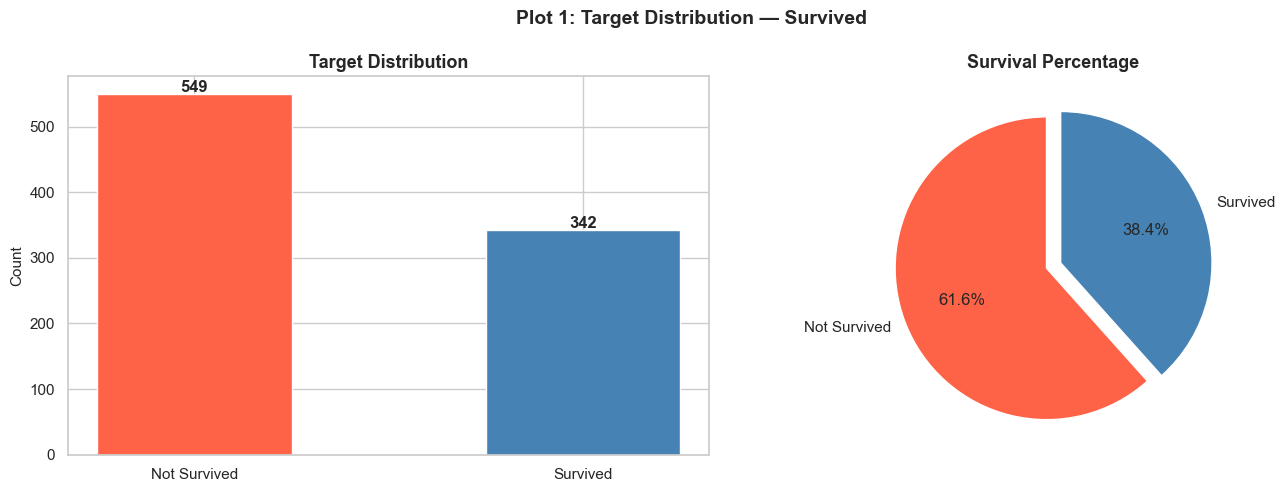

Saved: 01_target_distribution.png


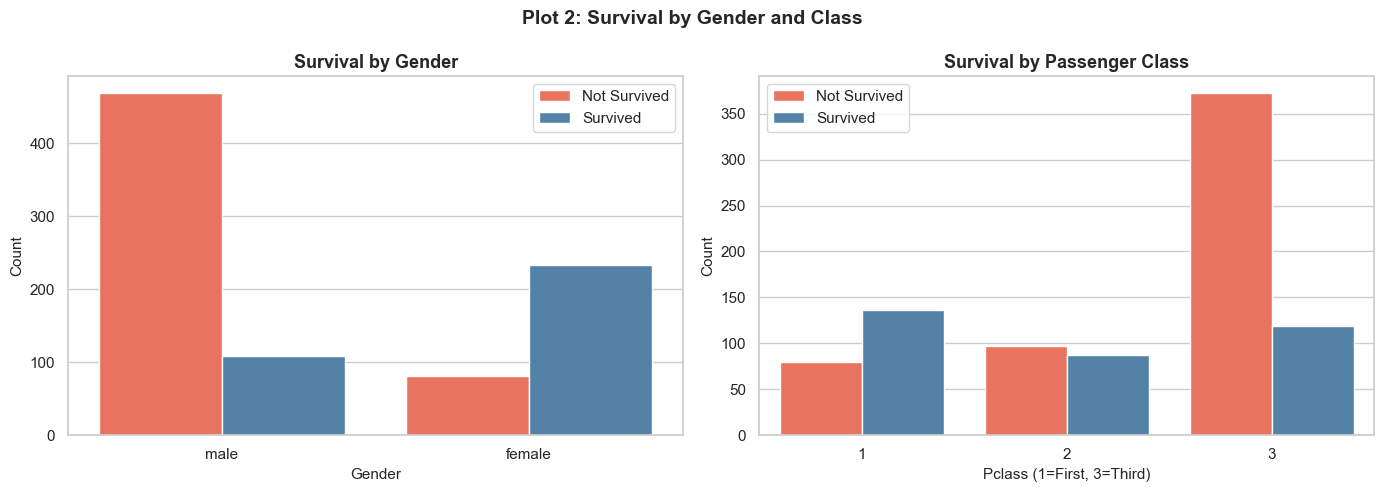

Saved: 02_survival_by_gender_class.png


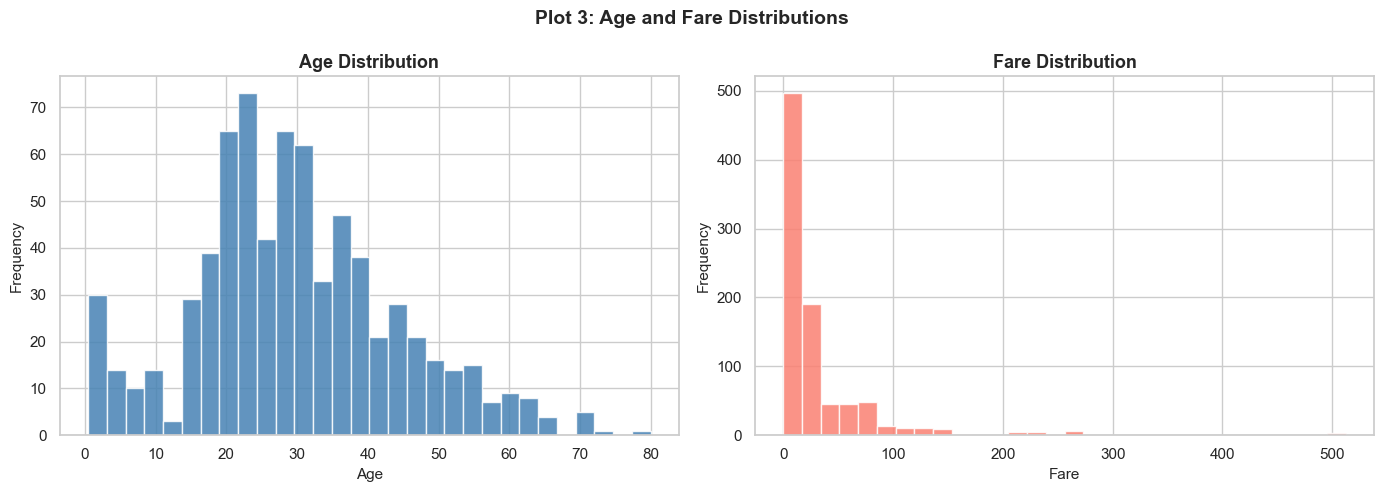

Saved: 03_age_fare_distribution.png


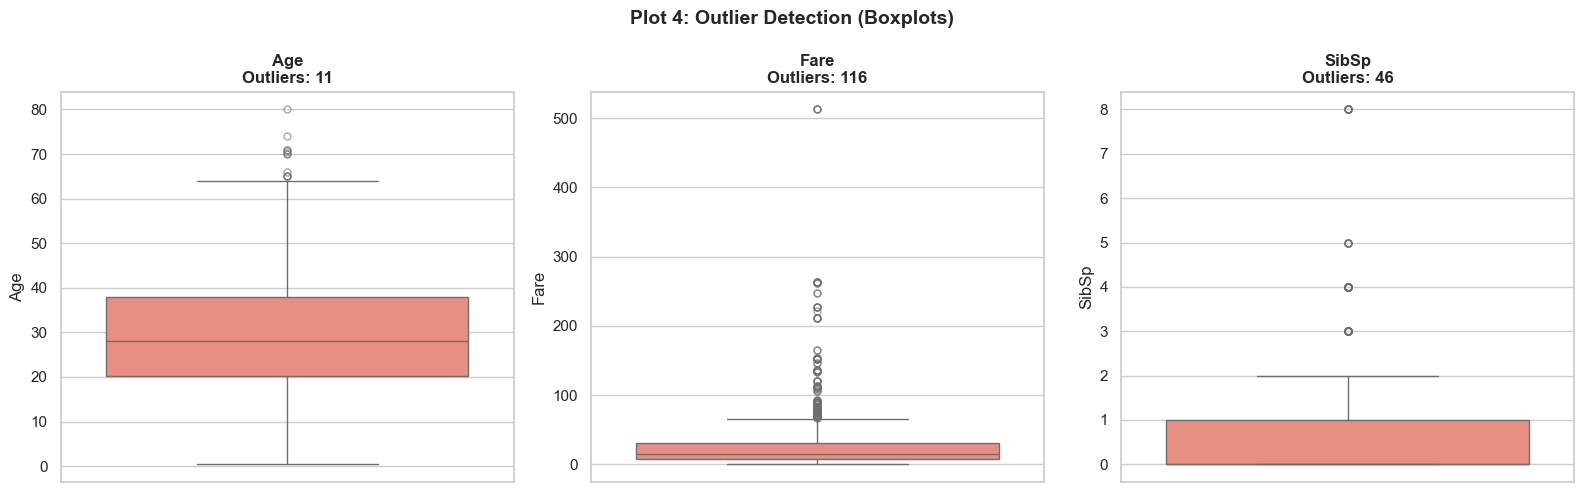

Saved: 04_outlier_boxplots.png


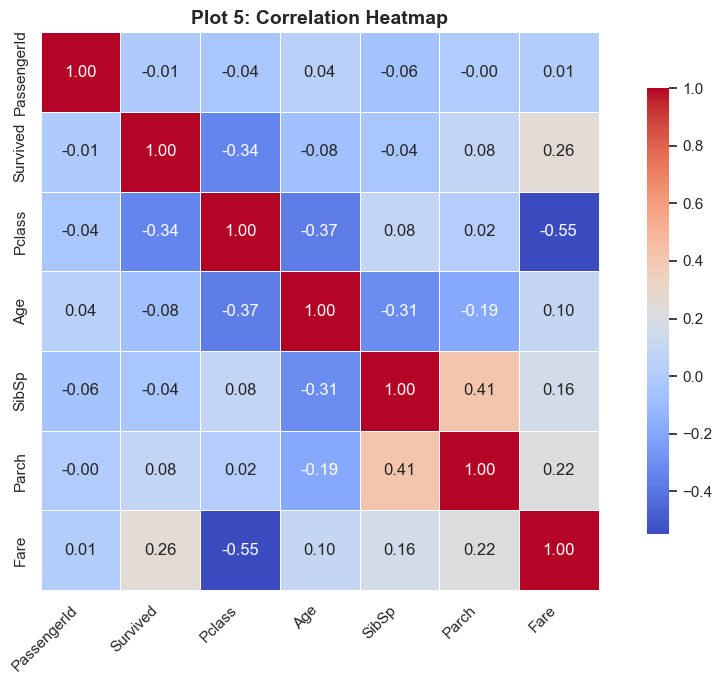

Saved: 05_correlation_heatmap.png


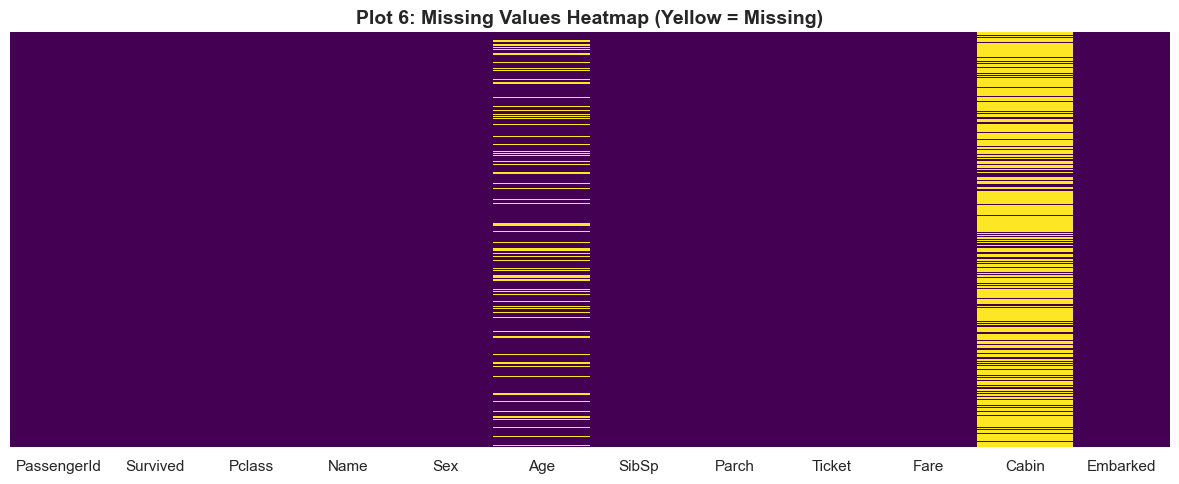

Saved: 06_missing_values_heatmap.png

All 6 EDA plots saved successfully!


In [33]:

# STAGE 2: Exploratory Data Analysis
# 6 key plots — each answers an important question

print("=" * 65)
print("STAGE 2 : EDA — GENERATING PLOTS")
print("=" * 65)

# ── Plot 1: Target Distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

survival_counts = df['Survived'].value_counts()
axes[0].bar(['Not Survived', 'Survived'],
            survival_counts.values,
            color=['tomato', 'steelblue'],
            edgecolor='white', width=0.5)
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=12, fontweight='bold')

axes[1].pie(survival_counts, labels=['Not Survived', 'Survived'],
            autopct='%1.1f%%', colors=['tomato', 'steelblue'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Survival Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Plot 1: Target Distribution — Survived', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, '01_target_distribution.png'), bbox_inches='tight')
plt.show()
print("Saved: 01_target_distribution.png")

# ── Plot 2: Survival by Gender and Pclass ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Sex', hue='Survived', data=df,
              palette={0: 'tomato', 1: 'steelblue'}, ax=axes[0])
axes[0].set_title('Survival by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Not Survived', 'Survived'])

sns.countplot(x='Pclass', hue='Survived', data=df,
              palette={0: 'tomato', 1: 'steelblue'}, ax=axes[1])
axes[1].set_title('Survival by Passenger Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pclass (1=First, 3=Third)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(['Not Survived', 'Survived'])

plt.suptitle('Plot 2: Survival by Gender and Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, '02_survival_by_gender_class.png'), bbox_inches='tight')
plt.show()
print("Saved: 02_survival_by_gender_class.png")

# ── Plot 3: Age and Fare Distribution ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'].dropna(), bins=30, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

axes[1].hist(df['Fare'].dropna(), bins=30, color='salmon',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Fare Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fare', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

plt.suptitle('Plot 3: Age and Fare Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, '03_age_fare_distribution.png'), bbox_inches='tight')
plt.show()
print("Saved: 03_age_fare_distribution.png")

# ── Plot 4: Outlier Detection Boxplots ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='salmon',
                flierprops=dict(marker='o', color='red', markersize=5, alpha=0.6))
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    axes[i].set_title(f'{col}\nOutliers: {n_out}', fontsize=12, fontweight='bold')

plt.suptitle('Plot 4: Outlier Detection (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, '04_outlier_boxplots.png'), bbox_inches='tight')
plt.show()
print("Saved: 04_outlier_boxplots.png")

# ── Plot 5: Correlation Heatmap ───────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Plot 5: Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, '05_correlation_heatmap.png'), bbox_inches='tight')
plt.show()
print("Saved: 05_correlation_heatmap.png")

# ── Plot 6: Missing Values Heatmap ───────────────────
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Plot 6: Missing Values Heatmap (Yellow = Missing)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, '06_missing_values_heatmap.png'), bbox_inches='tight')
plt.show()
print("Saved: 06_missing_values_heatmap.png")

print("\nAll 6 EDA plots saved successfully!")

In [34]:

# STAGE 3: Data Cleaning
# Fix every issue found during EDA

print("=" * 65)
print("STAGE 3 : DATA CLEANING")
print("=" * 65)

df_clean = df.copy()
cleaning_log = []

# ── Step 1: Drop irrelevant columns ──────────────────
# PassengerId : just an index — no predictive value
# Name        : too many unique values — not useful directly
# Ticket      : highly unique — not useful
# Cabin       : 77% missing — too much to impute
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean.drop(columns=drop_cols, inplace=True)
cleaning_log.append(('Dropped irrelevant columns',
                      f"Removed: {drop_cols}", len(df_clean)))
print(f"Step 1: Dropped columns: {drop_cols}")

# ── Step 2: Fill missing Age with median ─────────────
n_age_missing = df_clean['Age'].isnull().sum()
age_median    = df_clean['Age'].median()
df_clean['Age'].fillna(age_median, inplace=True)
cleaning_log.append(('Missing Age values',
                      f"Filled {n_age_missing} values with median ({age_median})",
                      n_age_missing))
print(f"Step 2: Age — filled {n_age_missing} missing values with median ({age_median})")

# ── Step 3: Fill missing Embarked with mode ───────────
n_emb_missing  = df_clean['Embarked'].isnull().sum()
embarked_mode  = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(embarked_mode, inplace=True)
cleaning_log.append(('Missing Embarked values',
                      f"Filled {n_emb_missing} values with mode ('{embarked_mode}')",
                      n_emb_missing))
print(f"Step 3: Embarked — filled {n_emb_missing} missing values with mode ('{embarked_mode}')")

# ── Step 4: Cap Fare outliers using IQR ──────────────
Q1_fare  = df_clean['Fare'].quantile(0.25)
Q3_fare  = df_clean['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
upper_fare = Q3_fare + 1.5 * IQR_fare
n_fare_out = (df_clean['Fare'] > upper_fare).sum()
df_clean['Fare'] = df_clean['Fare'].clip(upper=upper_fare)
cleaning_log.append(('Fare outliers',
                      f"Capped {n_fare_out} values above {upper_fare:.2f} using IQR",
                      n_fare_out))
print(f"Step 4: Fare — capped {n_fare_out} outliers above {upper_fare:.2f}")

# ── Step 5: Remove duplicate rows ────────────────────
n_dupes = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
cleaning_log.append(('Duplicate rows',
                      f"Removed {n_dupes} duplicate rows",
                      n_dupes))
print(f"Step 5: Removed {n_dupes} duplicate rows")

print(f"\nShape after cleaning : {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print(f"Missing values after cleaning:\n{df_clean.isnull().sum()}")

# Print cleaning log
print(f"\nCleaning Log Summary:")
print("-" * 65)
for i, (issue, action, rows) in enumerate(cleaning_log, 1):
    print(f"Step {i} | Issue: {issue}")
    print(f"        Action: {action}")
    print(f"        Rows Affected: {rows}")
    print("-" * 65)

STAGE 3 : DATA CLEANING
Step 1: Dropped columns: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Step 2: Age — filled 177 missing values with median (28.0)
Step 3: Embarked — filled 2 missing values with mode ('S')
Step 4: Fare — capped 116 outliers above 65.63
Step 5: Removed 118 duplicate rows

Shape after cleaning : 773 rows x 8 columns
Missing values after cleaning:
Survived      0
Pclass        0
Sex           0
Age         101
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Cleaning Log Summary:
-----------------------------------------------------------------
Step 1 | Issue: Dropped irrelevant columns
        Action: Removed: ['PassengerId', 'Name', 'Ticket', 'Cabin']
        Rows Affected: 891
-----------------------------------------------------------------
Step 2 | Issue: Missing Age values
        Action: Filled 177 values with median (28.0)
        Rows Affected: 177
-----------------------------------------------------------------
Step 3 | Issue: M

In [35]:

# STAGE 4: Feature Engineering + Full Preprocessing
# Encode categorical, scale numeric, handle all types

print("=" * 65)
print("STAGE 4 : FEATURE ENGINEERING AND PREPROCESSING")
print("=" * 65)

df_processed = df_clean.copy()

# ── Feature Engineering: FamilySize ──────────────────
# SibSp + Parch + 1 (self) = total family size on board
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
print("New feature created: FamilySize = SibSp + Parch + 1")

# ── Feature Engineering: IsAlone ─────────────────────
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
print("New feature created: IsAlone (1 = traveling alone, 0 = with family)")

# ── Feature Engineering: AgeBand ─────────────────────
# Binning Age into categories
df_processed['AgeBand'] = pd.cut(
    df_processed['Age'],
    bins  = [0, 12, 18, 35, 60, 100],
    labels= ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)
print("New feature created: AgeBand (age groups)")

# Drop SibSp and Parch — replaced by FamilySize
df_processed.drop(columns=['SibSp', 'Parch', 'Age'], inplace=True)
print("Dropped: SibSp, Parch, Age (replaced by engineered features)")

print(f"\nColumns after feature engineering: {df_processed.columns.tolist()}")
print(f"Shape: {df_processed.shape}")

# ── Identify final numeric and categorical columns ────
TARGET       = 'Survived'
X            = df_processed.drop(columns=[TARGET])
y            = df_processed[TARGET]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric Columns    : {num_cols}")
print(f"Categorical Columns: {cat_cols}")

# ── Build sklearn Pipeline ────────────────────────────
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric',     numeric_pipeline,     num_cols),
    ('categorical', categorical_pipeline, cat_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print(f"\nPipeline built successfully!")
print(full_pipeline)

STAGE 4 : FEATURE ENGINEERING AND PREPROCESSING
New feature created: FamilySize = SibSp + Parch + 1
New feature created: IsAlone (1 = traveling alone, 0 = with family)
New feature created: AgeBand (age groups)
Dropped: SibSp, Parch, Age (replaced by engineered features)

Columns after feature engineering: ['Survived', 'Pclass', 'Sex', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeBand']
Shape: (773, 8)

Numeric Columns    : ['Pclass', 'Fare', 'FamilySize', 'IsAlone']
Categorical Columns: ['Sex', 'Embarked', 'AgeBand']

Pipeline built successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
    

In [36]:

# STAGE 5: Train/Test Split — No Leakage
# Fit pipeline on train only, transform both sets

print("=" * 65)
print("STAGE 5 : TRAIN / TEST SPLIT AND TRANSFORMATION")
print("=" * 65)

# Split BEFORE fitting pipeline — prevents data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y   # maintain class balance in both sets
)

print(f"X shape (full)  : {X.shape}")
print(f"X_train shape   : {X_train.shape}")
print(f"X_test  shape   : {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test  distribution:\n{y_test.value_counts()}")

# Fit pipeline on TRAINING data only
full_pipeline.fit(X_train)

# Transform both sets
X_train_transformed = full_pipeline.transform(X_train)
X_test_transformed  = full_pipeline.transform(X_test)

# Get final feature names
ohe_feature_names = (
    full_pipeline
    .named_steps['preprocessor']
    .named_transformers_['categorical']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

print(f"\nX_train BEFORE transform : shape={X_train.shape}, dtype=mixed")
print(f"X_train AFTER  transform : shape={X_train_transformed.shape}, dtype={X_train_transformed.dtype}")
print(f"\nX_test  BEFORE transform : shape={X_test.shape},  dtype=mixed")
print(f"X_test  AFTER  transform : shape={X_test_transformed.shape},  dtype={X_test_transformed.dtype}")

print(f"\nTotal features after encoding: {X_train_transformed.shape[1]}")
print(f"Feature names: {all_feature_names}")

# Save as DataFrames for readability
train_final = pd.DataFrame(X_train_transformed, columns=all_feature_names)
train_final['Survived'] = y_train.values

test_final = pd.DataFrame(X_test_transformed, columns=all_feature_names)
test_final['Survived'] = y_test.values

print(f"\nSample of final training data (first 3 rows):")
print(train_final.head(3).round(4))

STAGE 5 : TRAIN / TEST SPLIT AND TRANSFORMATION
X shape (full)  : (773, 7)
X_train shape   : (618, 7)
X_test  shape   : (155, 7)
y_train distribution:
Survived
0    366
1    252
Name: count, dtype: int64
y_test  distribution:
Survived
0    92
1    63
Name: count, dtype: int64

X_train BEFORE transform : shape=(618, 7), dtype=mixed
X_train AFTER  transform : shape=(618, 14), dtype=float64

X_test  BEFORE transform : shape=(155, 7),  dtype=mixed
X_test  AFTER  transform : shape=(155, 14),  dtype=float64

Total features after encoding: 14
Feature names: ['Pclass', 'Fare', 'FamilySize', 'IsAlone', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_Young Adult']

Sample of final training data (first 3 rows):
   Pclass    Fare  FamilySize  IsAlone  Sex_female  Sex_male  Embarked_C  \
0  0.8575  0.2420      2.5876  -1.1695         0.0       1.0         0.0   
1  0.8575 -0.7429     -0.6094   0.8550   

In [37]:

# STAGE 6: Save all outputs to organised folder
# Clean dataset, train/test splits, fitted pipeline

print("=" * 65)
print("STAGE 6 : SAVING ALL OUTPUTS")
print("=" * 65)

# Save clean dataset
clean_path = os.path.join(data_folder, 'titanic_clean.csv')
df_clean.to_csv(clean_path, index=False)
print(f"Saved: titanic_clean.csv ({df_clean.shape[0]} rows)")

# Save processed training set
train_path = os.path.join(data_folder, 'train_processed.csv')
train_final.to_csv(train_path, index=False)
print(f"Saved: train_processed.csv ({train_final.shape[0]} rows)")

# Save processed test set
test_path = os.path.join(data_folder, 'test_processed.csv')
test_final.to_csv(test_path, index=False)
print(f"Saved: test_processed.csv ({test_final.shape[0]} rows)")

# Save fitted pipeline using joblib
pipeline_path = os.path.join(models_folder, 'fitted_pipeline.joblib')
joblib.dump(full_pipeline, pipeline_path)
file_size = os.path.getsize(pipeline_path) / 1024
print(f"Saved: fitted_pipeline.joblib ({file_size:.2f} KB)")

print(f"\nAll outputs saved to: '{output_folder}/'")

STAGE 6 : SAVING ALL OUTPUTS
Saved: titanic_clean.csv (773 rows)
Saved: train_processed.csv (618 rows)
Saved: test_processed.csv (155 rows)
Saved: fitted_pipeline.joblib (3.94 KB)

All outputs saved to: 'titanic_project_output/'


In [38]:

# STAGE 7: Write README.txt
# Dataset summary + EDA findings + all preprocessing decisions

readme_content = f"""
================================================================================
         TITANIC DATASET — COMPLETE ML PIPELINE PROJECT
         README.txt
================================================================================

DATASET SUMMARY
---------------
Source              : Kaggle — Titanic: Machine Learning from Disaster
File Used           : train.csv
Original Shape      : {df_raw.shape[0]} rows x {df_raw.shape[1]} columns
Final Clean Shape   : {df_clean.shape[0]} rows x {df_clean.shape[1]} columns
Target Variable     : Survived (0 = Not Survived, 1 = Survived)
Task Type           : Binary Classification

COLUMNS IN RAW DATASET
-----------------------
PassengerId : Unique ID for each passenger (dropped)
Survived    : Target variable (0/1)
Pclass      : Passenger class (1, 2, 3)
Name        : Passenger name (dropped)
Sex         : Gender (male/female)
Age         : Age in years (20% missing)
SibSp       : Siblings/spouses aboard
Parch       : Parents/children aboard
Ticket      : Ticket number (dropped)
Cabin       : Cabin number (77% missing — dropped)
Embarked    : Port of embarkation (C, Q, S)
Fare        : Ticket fare

================================================================================
KEY FINDINGS FROM EDA
================================================================================

1. TARGET DISTRIBUTION (Class Imbalance)
   - Not Survived : 549 passengers (61.6%)
   - Survived     : 342 passengers (38.4%)
   - Mild class imbalance detected

2. SURVIVAL BY GENDER
   - Female survival rate is significantly higher than male
   - "Women and children first" pattern clearly visible in data

3. SURVIVAL BY CLASS
   - 1st class passengers had highest survival rate
   - 3rd class passengers had lowest survival rate
   - Pclass is a strong predictor of survival

4. MISSING VALUES FOUND
   - Age     : {df_raw['Age'].isnull().sum()} missing ({df_raw['Age'].isnull().mean()*100:.1f}%) — imputed with median
   - Cabin   : {df_raw['Cabin'].isnull().sum()} missing ({df_raw['Cabin'].isnull().mean()*100:.1f}%) — column dropped
   - Embarked: {df_raw['Embarked'].isnull().sum()} missing — imputed with mode

5. OUTLIERS
   - Fare has significant right-skewed outliers (some > 500)
   - Age has mild outliers at higher end (80+)
   - SibSp has a few high outliers

6. CORRELATIONS
   - Fare    : Positive correlation with survival (+0.26)
   - Pclass  : Negative correlation with survival (-0.34)
   - Age     : Slight negative correlation (-0.07)

================================================================================
PREPROCESSING DECISIONS
================================================================================

STEP 1 — DROPPED COLUMNS
   Reason   : Not useful for prediction
   Columns  : PassengerId, Name, Ticket, Cabin
   Decision : PassengerId is just an index.
              Name and Ticket are too unique to generalise.
              Cabin has 77% missing — imputation unreliable.

STEP 2 — MISSING AGE IMPUTATION
   Missing  : {df_raw['Age'].isnull().sum()} rows (20%)
   Strategy : Filled with median age ({df_clean['Age'].median():.1f})
   Reason   : Median is robust to outliers unlike mean.

STEP 3 — MISSING EMBARKED IMPUTATION
   Missing  : 2 rows
   Strategy : Filled with mode (most frequent port)
   Reason   : Only 2 values missing — mode fill is safe.

STEP 4 — FARE OUTLIER CAPPING
   Method   : IQR capping (clip values above Q3 + 1.5*IQR)
   Reason   : Extreme outliers can skew model training.
              Capping preferred over removal to keep rows.

STEP 5 — FEATURE ENGINEERING
   FamilySize = SibSp + Parch + 1
              Captures total family presence on board.
   IsAlone    = 1 if FamilySize == 1 else 0
              Simpler binary signal for solo travellers.
   AgeBand    = Age grouped into: Child, Teen, Young Adult, Adult, Senior
              Reduces noise in continuous age variable.

STEP 6 — PIPELINE PREPROCESSING
   Numeric columns   : SimpleImputer(median) → StandardScaler
   Categorical cols  : SimpleImputer(mode) → OneHotEncoder
   Pipeline fit on   : X_train only (no data leakage)
   Pipeline applied  : X_train and X_test separately

STEP 7 — TRAIN/TEST SPLIT
   Split ratio       : 80% train / 20% test
   Stratified        : Yes (class balance maintained in both sets)
   X_train shape     : {X_train_transformed.shape}
   X_test  shape     : {X_test_transformed.shape}

================================================================================
OUTPUT FILES
================================================================================

plots/
   01_target_distribution.png
   02_survival_by_gender_class.png
   03_age_fare_distribution.png
   04_outlier_boxplots.png
   05_correlation_heatmap.png
   06_missing_values_heatmap.png

data/
   titanic_clean.csv        — cleaned raw dataset
   train_processed.csv      — model-ready training set
   test_processed.csv       — model-ready test set

models/
   fitted_pipeline.joblib   — saved sklearn pipeline

README.txt                  — this file

================================================================================
"""

readme_path = os.path.join(output_folder, 'README.txt')
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("README.txt written successfully!")
print(readme_content)

README.txt written successfully!

         TITANIC DATASET — COMPLETE ML PIPELINE PROJECT
         README.txt

DATASET SUMMARY
---------------
Source              : Kaggle — Titanic: Machine Learning from Disaster
File Used           : train.csv
Original Shape      : 891 rows x 12 columns
Final Clean Shape   : 773 rows x 8 columns
Target Variable     : Survived (0 = Not Survived, 1 = Survived)
Task Type           : Binary Classification

COLUMNS IN RAW DATASET
-----------------------
PassengerId : Unique ID for each passenger (dropped)
Survived    : Target variable (0/1)
Pclass      : Passenger class (1, 2, 3)
Name        : Passenger name (dropped)
Sex         : Gender (male/female)
Age         : Age in years (20% missing)
SibSp       : Siblings/spouses aboard
Parch       : Parents/children aboard
Ticket      : Ticket number (dropped)
Cabin       : Cabin number (77% missing — dropped)
Embarked    : Port of embarkation (C, Q, S)
Fare        : Ticket fare

KEY FINDINGS FROM EDA

1. TARGE

In [39]:

# Complete project summary — all stages recap

saved_files = []
for root, dirs, files in os.walk(output_folder):
    for file in files:
        rel_path = os.path.relpath(os.path.join(root, file), output_folder)
        saved_files.append(rel_path)

print("=" * 65)
print("       TITANIC ML PIPELINE — PROJECT COMPLETE")
print("=" * 65)

print(f"""
PIPELINE STAGES COMPLETED:

   Stage 1 : Load and Inspect          (891 rows x 12 cols)
   Stage 2 : EDA — 6 plots generated
   Stage 3 : Data Cleaning             (5 steps applied)
   Stage 4 : Feature Engineering       (3 new features)
   Stage 5 : Preprocessing Pipeline    (sklearn Pipeline)
   Stage 6 : Train/Test Split          (80/20 stratified)
   Stage 7 : All outputs saved
   Stage 8 : README.txt written
""")

print(f"Output Folder: '{output_folder}/'")
print(f"\nAll saved files ({len(saved_files)} total):")
for f in sorted(saved_files):
    print(f"   {f}")

print("\n" + "=" * 65)
print("Project pipeline completed successfully.")
print("=" * 65)



       TITANIC ML PIPELINE — PROJECT COMPLETE

PIPELINE STAGES COMPLETED:

   Stage 1 : Load and Inspect          (891 rows x 12 cols)
   Stage 2 : EDA — 6 plots generated
   Stage 3 : Data Cleaning             (5 steps applied)
   Stage 4 : Feature Engineering       (3 new features)
   Stage 5 : Preprocessing Pipeline    (sklearn Pipeline)
   Stage 6 : Train/Test Split          (80/20 stratified)
   Stage 7 : All outputs saved
   Stage 8 : README.txt written

Output Folder: 'titanic_project_output/'

All saved files (11 total):
   README.txt
   data\test_processed.csv
   data\titanic_clean.csv
   data\train_processed.csv
   models\fitted_pipeline.joblib
   plots\01_target_distribution.png
   plots\02_survival_by_gender_class.png
   plots\03_age_fare_distribution.png
   plots\04_outlier_boxplots.png
   plots\05_correlation_heatmap.png
   plots\06_missing_values_heatmap.png

Project pipeline completed successfully.
